In [31]:
# ============================================================
# PROJET : Classification de Firewall Log Files avec SVM
# Fichier utilisé : log2.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)



***Chargement, préparation des données et encodage des classes***

In [32]:
# ------------------------------------------------------------
# 1) Chargement des données
# ------------------------------------------------------------
df = pd.read_csv("log2.csv")

print("Aperçu du dataset :")
print(df.head())
print("\nDimensions :", df.shape)

print("\nTypes de colonnes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

print("\nRépartition des classes :")
print(df["Action"].value_counts())

# ------------------------------------------------------------
# 2) Préparation des données
# ------------------------------------------------------------
X = df.drop(columns=["Action"])
y = df["Action"]

# Encodage des classes
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nClasses encodées :")
for i, c in enumerate(le.classes_):
    print(f"{c} -> {i}")

# Découpage train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)



Aperçu du dataset :
   Source Port  Destination Port  NAT Source Port  NAT Destination Port  \
0        57222                53            54587                    53   
1        56258              3389            56258                  3389   
2         6881             50321            43265                 50321   
3        50553              3389            50553                  3389   
4        50002               443            45848                   443   

  Action  Bytes  Bytes Sent  Bytes Received  Packets  Elapsed Time (sec)  \
0  allow    177          94              83        2                  30   
1  allow   4768        1600            3168       19                  17   
2  allow    238         118             120        2                1199   
3  allow   3327        1438            1889       15                  17   
4  allow  25358        6778           18580       31                  16   

   pkts_sent  pkts_received  
0          1              1  
1         10

***SVM Linéaire***


Rapport de classification :
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7528
        deny       0.99      0.96      0.98      2998
        drop       0.96      1.00      0.98      2570
  reset-both       0.00      0.00      0.00        11

    accuracy                           0.99     13107
   macro avg       0.74      0.74      0.74     13107
weighted avg       0.99      0.99      0.99     13107



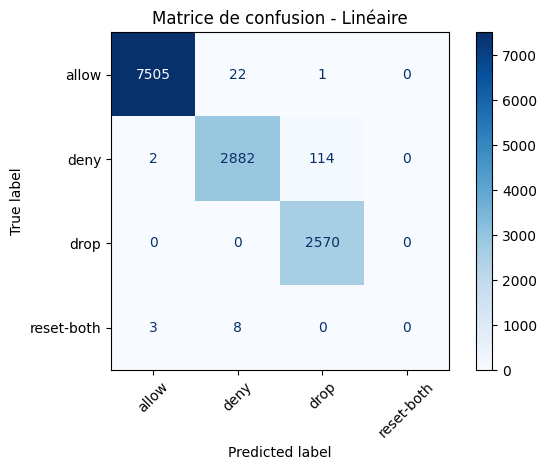

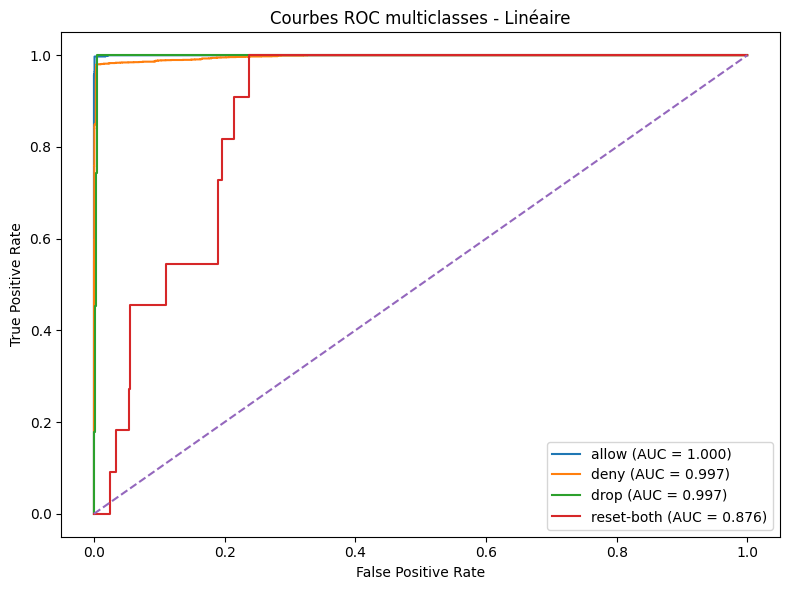

In [ ]:
# ------------------------------------------------------------
# 3) Définition des modèles SVM à comparer
# ------------------------------------------------------------
results = []

# Pour ROC multiclasses
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = len(le.classes_)

# ------------------------------------------------------------
# 4) Entraînement et évaluation
# ------------------------------------------------------------

pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="linear", probability=True, random_state=42))])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

results.append({"Méthode": "Linéaire","Précision": precision,"Recall": recall,"F1-score": f1})

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - Linéaire")
plt.tight_layout()
plt.show()

# ROC multiclasses
y_score = pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FP Rate (1-Specificity)")
plt.ylabel("TP Rate")
plt.title("Courbes ROC multiclasses - Linéaire")
plt.legend()
plt.tight_layout()
plt.show()



***SVM Polynomiale***


Rapport de classification :
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7528
        deny       0.99      0.96      0.98      2998
        drop       0.96      1.00      0.98      2570
  reset-both       0.00      0.00      0.00        11

    accuracy                           0.99     13107
   macro avg       0.74      0.74      0.74     13107
weighted avg       0.99      0.99      0.99     13107



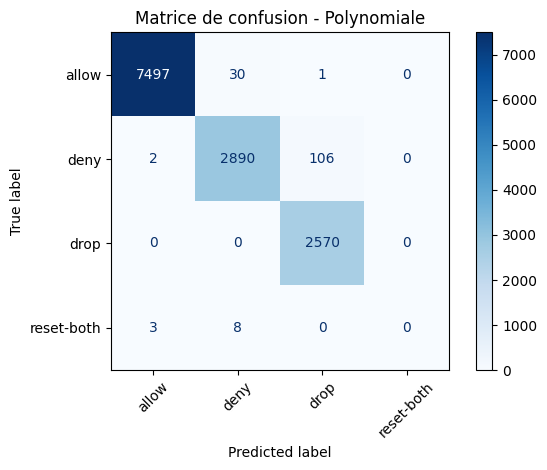

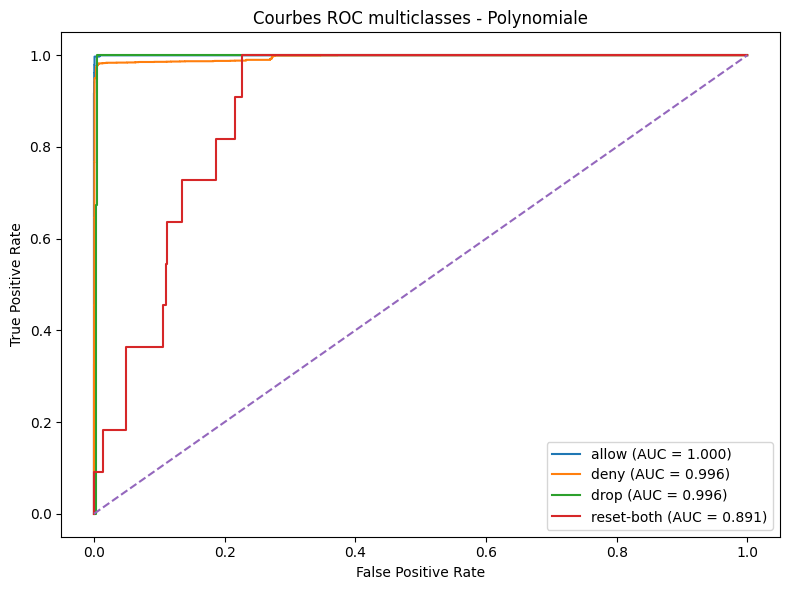

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, random_state=42))])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

results.append({"Méthode": "Polynomiale","Précision": precision,"Recall": recall,"F1-score": f1})

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - Polynomiale")
plt.tight_layout()
plt.show()

# ROC multiclasses
y_score = pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FP Rate (1-Specificity)")
plt.ylabel("TP Rate")
plt.title("Courbes ROC multiclasses - Polynomiale")
plt.legend()
plt.tight_layout()
plt.show()

***SVM RBF***


Rapport de classification :
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7528
        deny       0.99      0.96      0.98      2998
        drop       0.96      1.00      0.98      2570
  reset-both       0.00      0.00      0.00        11

    accuracy                           0.99     13107
   macro avg       0.74      0.74      0.74     13107
weighted avg       0.99      0.99      0.99     13107



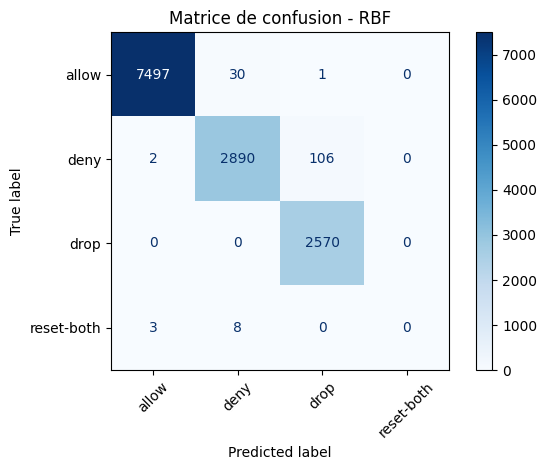

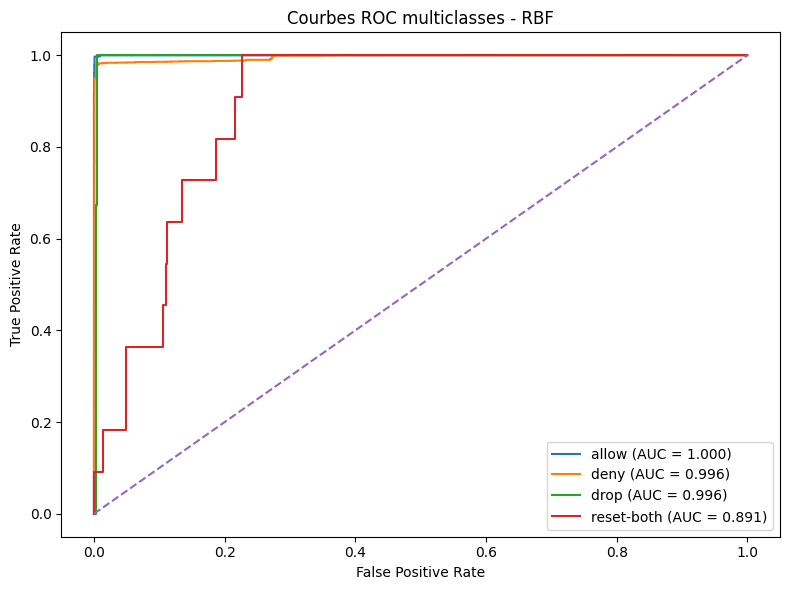

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True, random_state=42))])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

results.append({"Méthode": "RBF","Précision": precision,"Recall": recall,"F1-score": f1})

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - RBF")
plt.tight_layout()
plt.show()

# ROC multiclasses
y_score = pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FP Rate (1-Specificity)")
plt.ylabel("TP Rate")
plt.title("Courbes ROC multiclasses - RBF")
plt.legend()
plt.tight_layout()
plt.show()

***SVM SIGMOID***


Rapport de classification :
              precision    recall  f1-score   support

       allow       0.96      0.95      0.95      7528
        deny       0.95      0.86      0.90      2998
        drop       0.84      0.96      0.89      2570
  reset-both       0.00      0.00      0.00        11

    accuracy                           0.93     13107
   macro avg       0.69      0.69      0.69     13107
weighted avg       0.93      0.93      0.93     13107



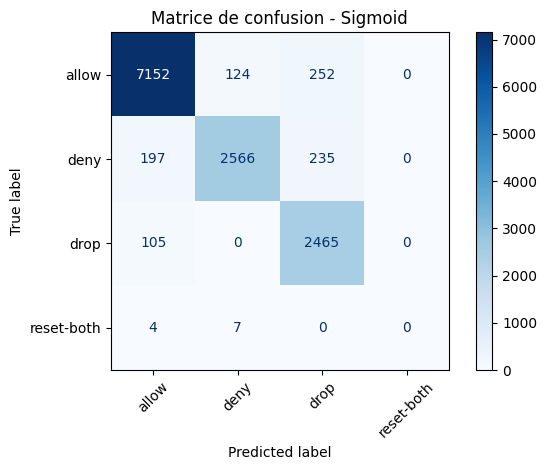

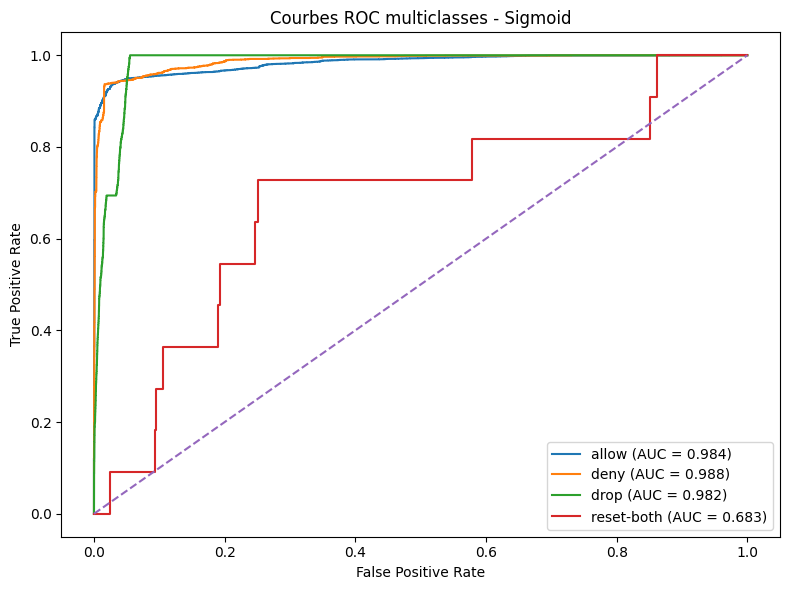

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="sigmoid", probability=True, random_state=42))])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

results.append({"Méthode": "sigmoid","Précision": precision,"Recall": recall,"F1-score": f1})

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion - Sigmoid")
plt.tight_layout()
plt.show()

# ROC multiclasses
y_score = pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FP Rate (1-Specificity)")
plt.ylabel("TP Rate")
plt.title("Courbes ROC multiclasses - Sigmoid")
plt.legend()
plt.tight_layout()
plt.show()

***Tableau récapitulatif***

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False)

print("\nRésumé des performances :")
print(results_df)

# Affichage en pourcentage
results_percent = results_df.copy()
for col in ["Précision", "Recall", "F1-score"]:
    results_percent[col] = (results_percent[col] * 100).round(2)

print("\nRésumé en pourcentage :")
print(results_percent)


Résumé des performances :
       Méthode  Précision    Recall  F1-score
1  Polynomiale   0.987972  0.988556  0.988151
2          RBF   0.987972  0.988556  0.988151
0     Linéaire   0.988024  0.988556  0.988150
3      sigmoid   0.932138  0.929503  0.929389

Résumé en pourcentage :
       Méthode  Précision  Recall  F1-score
1  Polynomiale      98.80   98.86     98.82
2          RBF      98.80   98.86     98.82
0     Linéaire      98.80   98.86     98.81
3      sigmoid      93.21   92.95     92.94


***Graphique comparatif***

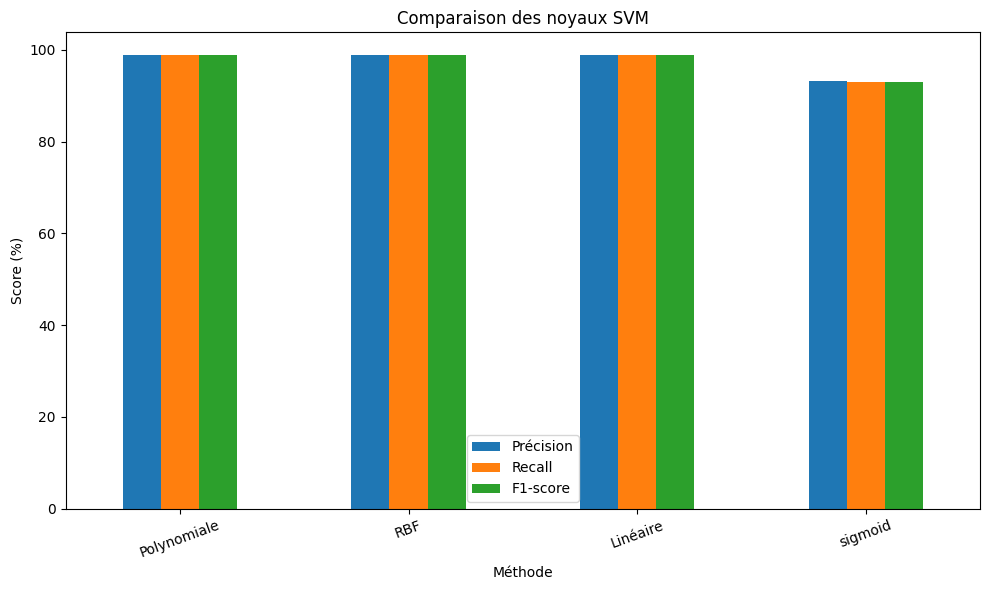

In [ ]:
results_plot = results_percent.set_index("Méthode")
results_plot.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Score (%)")
plt.title("Comparaison des noyaux SVM")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()